<a href="https://colab.research.google.com/github/CloneKitty/Phishing-detection-using-PhiUSIIL-Phishing-URL-Dataset/blob/v1/ATCS_Assignment_PartB_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

Dataset Load

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ACTS Assignment/PhiUSIIL_Phishing_URL_Dataset.csv')

print(f'Dataset Shape    : {df.shape}')

Dataset Shape    : (235795, 56)


Standardizing the Phishing Target Labels

In [ ]:
df["label"] = df["label"].astype(int)

df["label"].value_counts().rename(index={
    0: "Phishing",
    1: "Legitimate"
})

,count
label,
Legitimate,134850
Phishing,100945


Generating the URL Length Density Plot

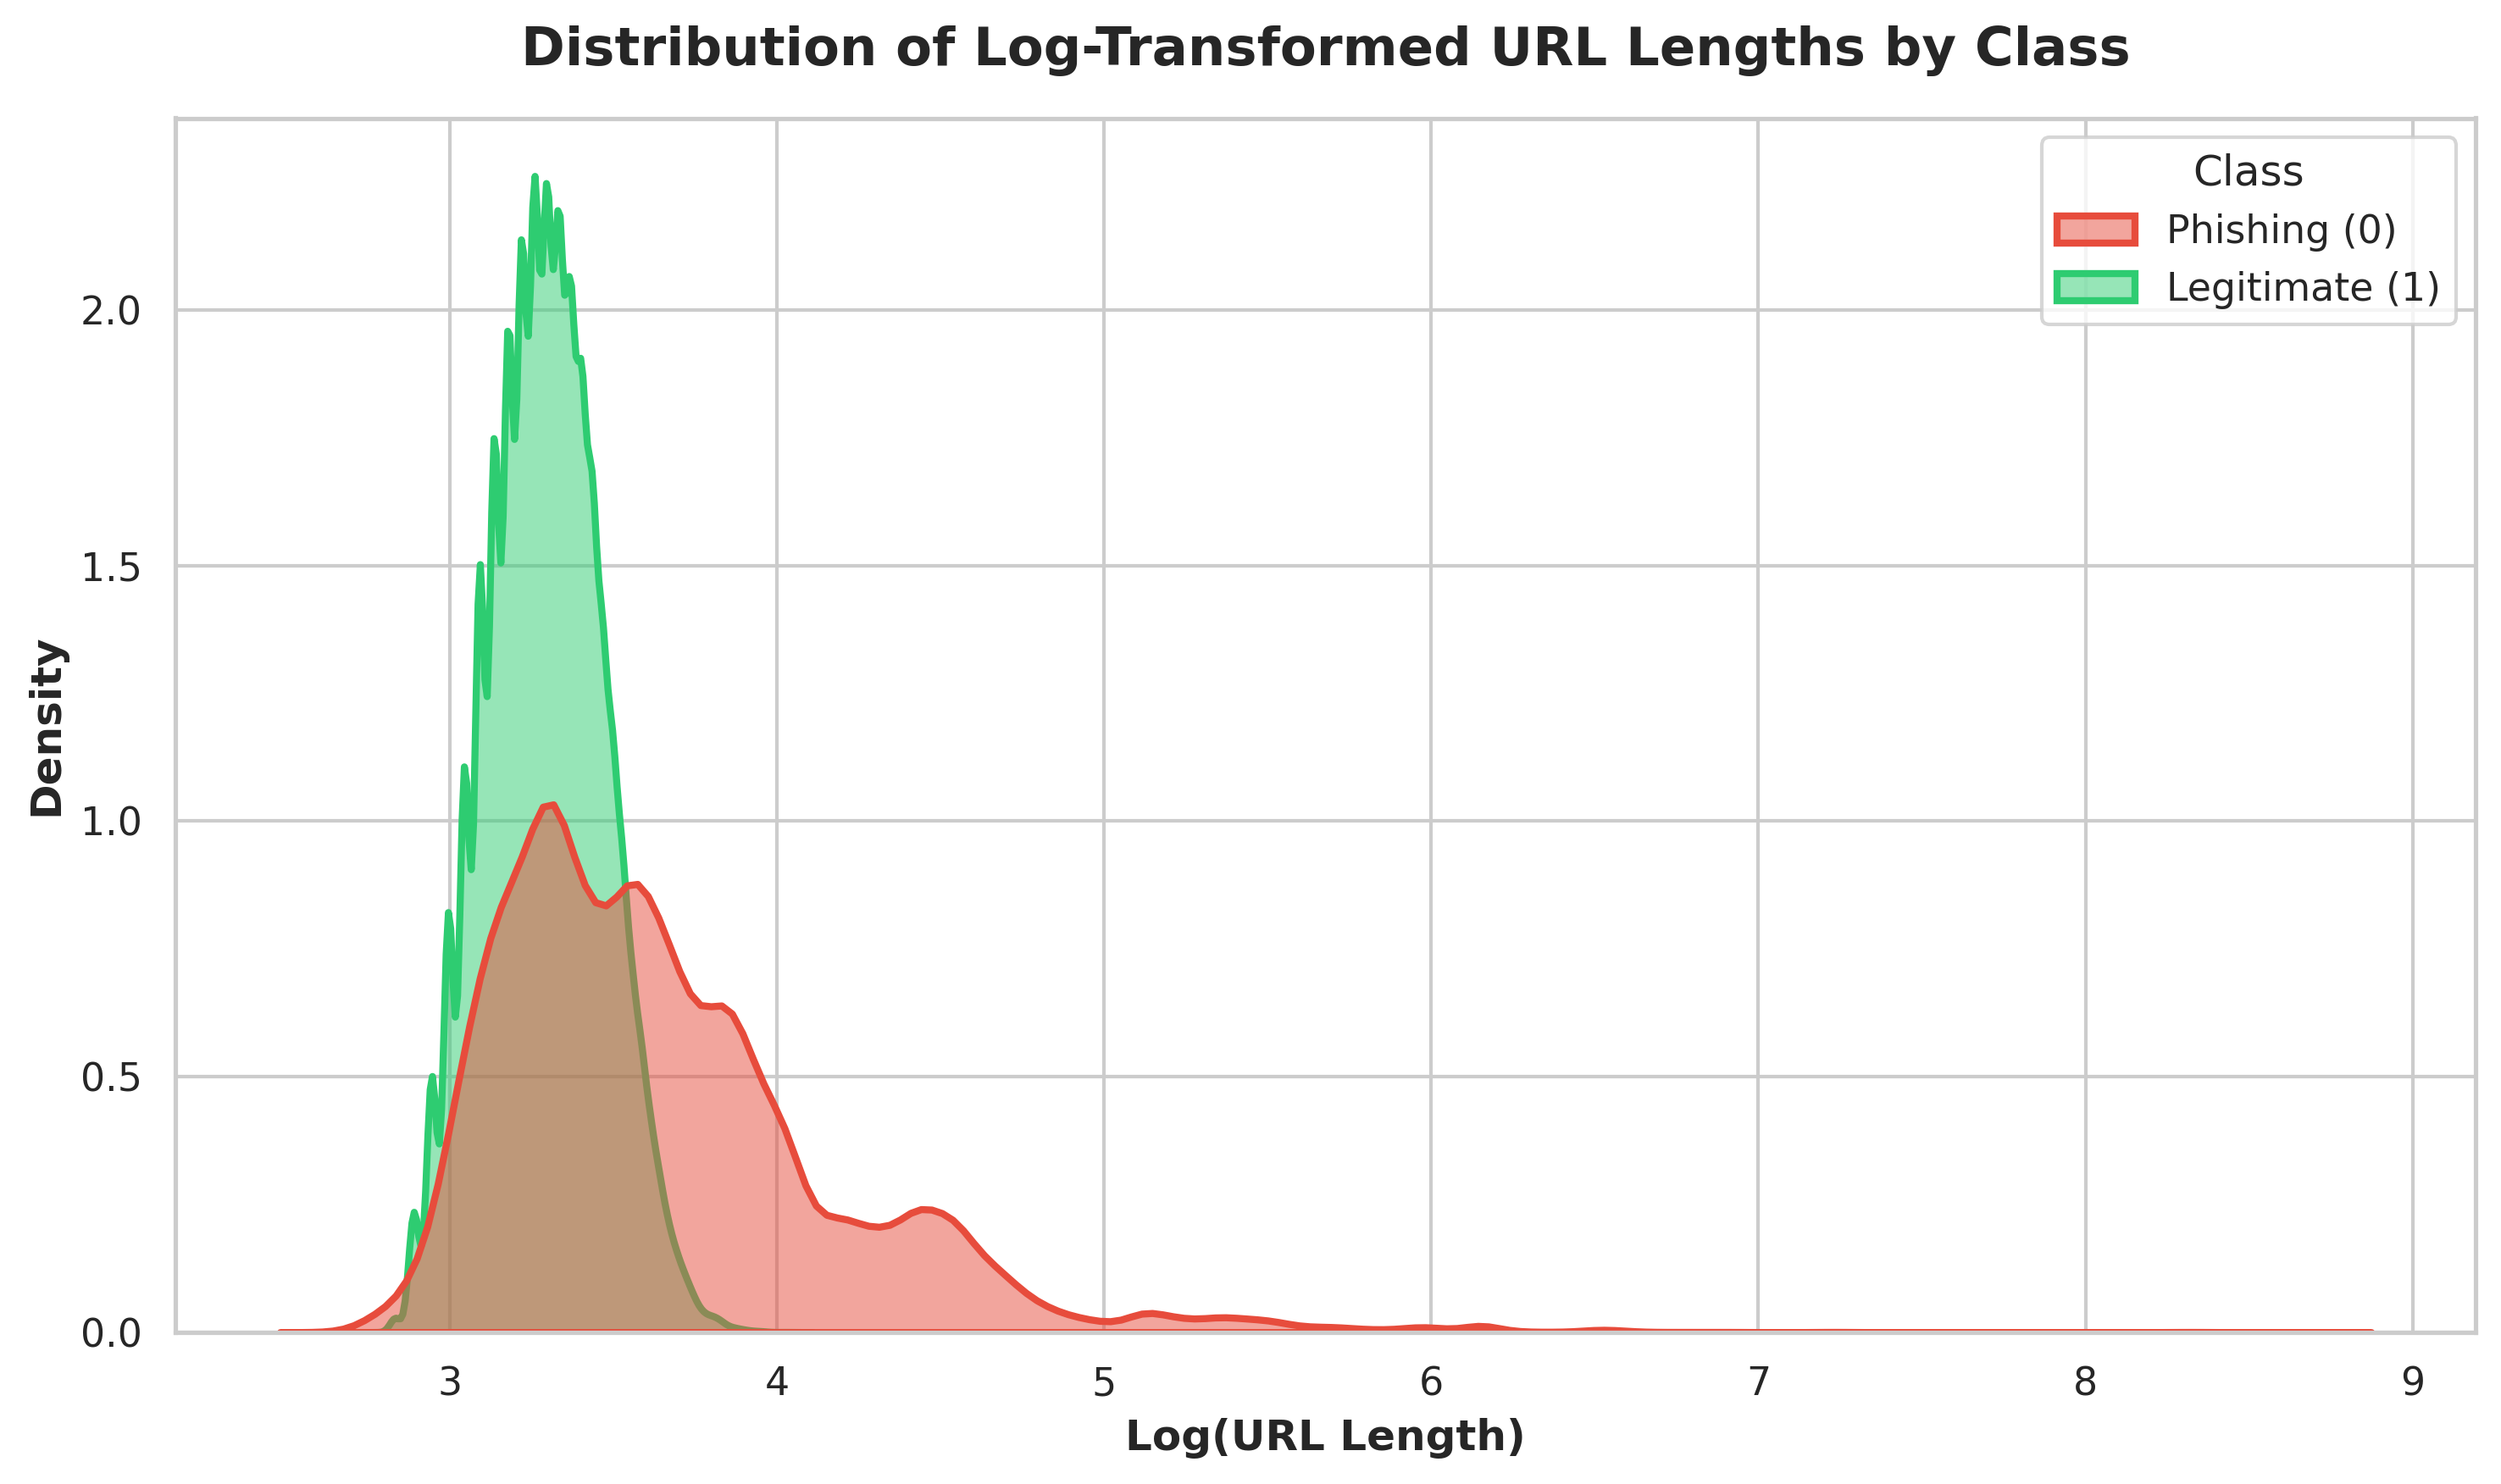

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6), dpi=300)

# Create log-transformed URL length column
df['LogURLLength'] = np.log1p(df['URLLength'])

color_map = {
    0: '#e74c3c',  # Phishing = red
    1: '#2ecc71'   # Legitimate = green
}

ax = sns.kdeplot(
    data=df,
    x='LogURLLength',
    hue='label',
    hue_order=[0, 1],
    fill=True,
    common_norm=False,
    palette=color_map,
    alpha=0.5,
    linewidth=2
)

plt.title(
    'Distribution of Log-Transformed URL Lengths by Class',
    fontsize=15,
    fontweight='bold',
    pad=15
)

plt.xlabel('Log(URL Length)', fontsize=12, fontweight='bold')
plt.ylabel('Density', fontsize=12, fontweight='bold')

legend = ax.get_legend()
if legend is not None:
    legend.set_title('Class')
    legend.texts[0].set_text('Phishing (0)')
    legend.texts[1].set_text('Legitimate (1)')

plt.tight_layout()
plt.savefig('url_length_distribution.png', bbox_inches='tight')
plt.show()

Target Variable Frequency Analysis

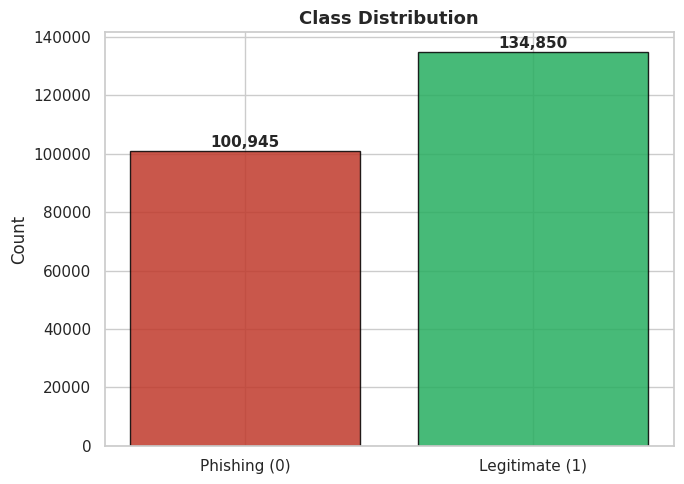

In [ ]:
plt.figure(figsize=(7, 5))

# Class distribution
class_labels = ['Phishing (0)', 'Legitimate (1)']
class_counts = [
    (df['label'] == 0).sum(),
    (df['label'] == 1).sum()
]

plt.bar(
    class_labels,
    class_counts,
    color=['#c0392b', '#27ae60'],
    edgecolor='black',
    alpha=0.85
)

plt.title('Class Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Count')

for i, v in enumerate(class_counts):
    plt.text(i, v + 1500, f'{v:,}', ha='center',
             fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

EDA

Feature Extraction: Syntax and Keyword Indicators

In [ ]:
df["HasAtSymbol"] = df["URL"].str.contains("@", na=False).astype(int)

df["DotCount"] = df["URL"].str.count(r"\.")

df["HyphenCount"] = df["URL"].str.count("-")

df["HasDoubleSlash"] = df["URL"].apply(
    lambda x: 1 if "//" in str(x)[7:] else 0
)

df["IsLongURL"] = (df["URLLength"] > 75).astype(int)

df["SubdomainDepth"] = df["URL"].str.count(r"\.") - 1

df["HasSuspiciousKeyword"] = df["URL"].str.contains(
    "login|secure|account|update|verify|bank|paypal|confirm",
    case=False,
    na=False
).astype(int)

In [ ]:
https_summary = pd.DataFrame({
    'Total URLs': df.groupby('label').size(),
    'HTTPS URLs': df.groupby('label')['IsHTTPS'].sum(),
    'HTTPS Percentage': df.groupby('label')['IsHTTPS'].mean() * 100
})

https_summary.index = ['Phishing (0)', 'Legitimate (1)']
https_summary['HTTPS Percentage'] = https_summary['HTTPS Percentage'].round(2)

https_summary

,Total URLs,HTTPS URLs,HTTPS Percentage
Phishing (0),100945,49689,49.22
Legitimate (1),134850,134850,100.00


Isolating Pre-Visit Lexical Features for Model Training

In [ ]:
safe_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "CharContinuationRate",
    "HasAtSymbol",
    "DotCount",
    "HyphenCount",
    "HasDoubleSlash",
    "IsLongURL",
    "SubdomainDepth",
    "HasSuspiciousKeyword"
]

X = df[safe_features]
y = df["label"]

In [ ]:
Correlation Heatmap

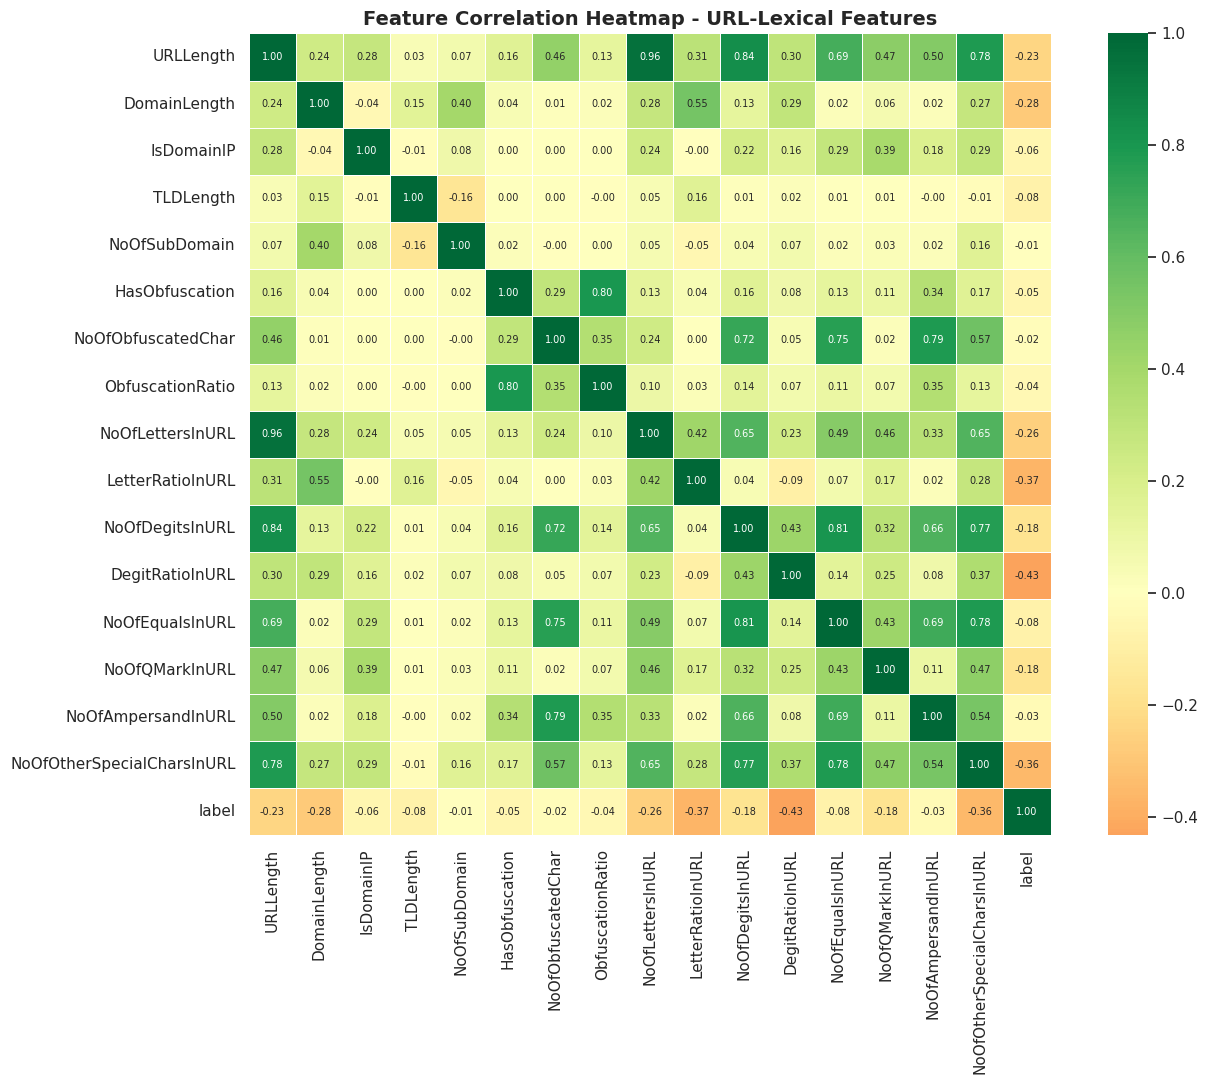

In [ ]:
# Correlation heatmap of selected URL-based features

heatmap_features = safe_features[:16] + ['label']

plt.figure(figsize=(14, 11))

corr = df[heatmap_features].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={'size': 7}
)

plt.title(
    'Feature Correlation Heatmap - URL-Lexical Features',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Establishing the Evaluation Framework: 80/20 Stratified Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Random Forest feature selection

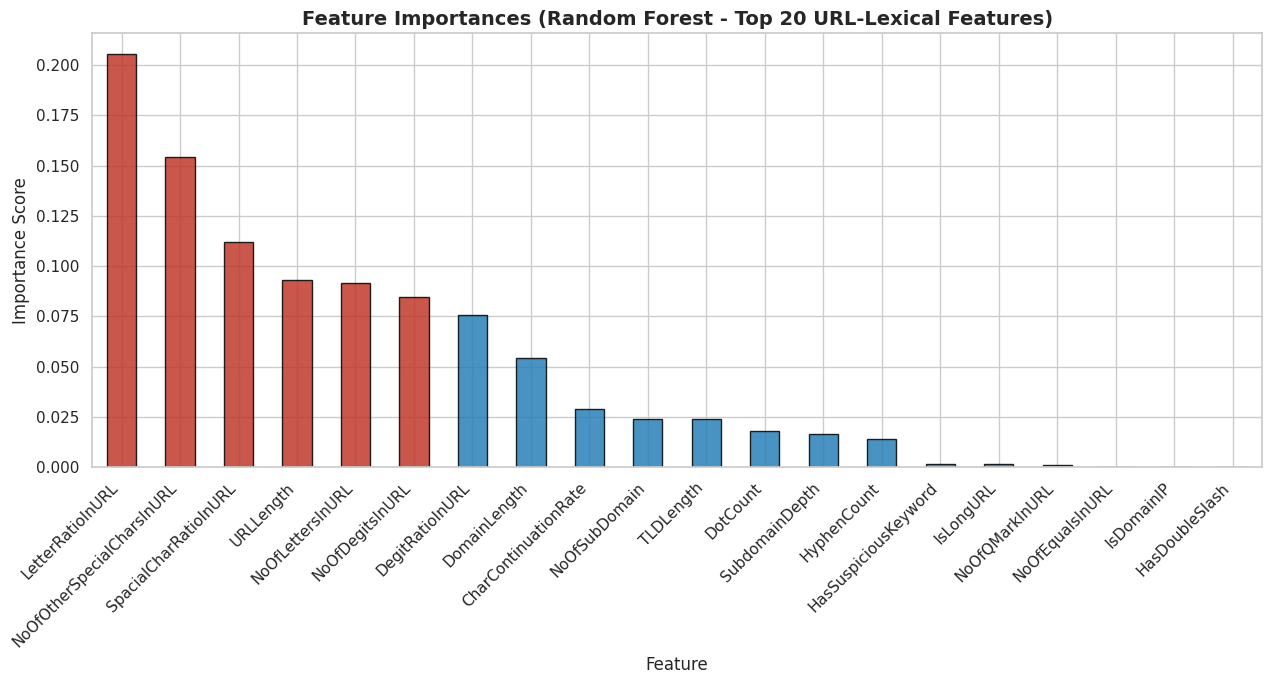


Top 20 Features Selected by Random Forest:
 1. LetterRatioInURL                    0.20547
 2. NoOfOtherSpecialCharsInURL          0.15433
 3. SpacialCharRatioInURL               0.11184
 4. URLLength                           0.09302
 5. NoOfLettersInURL                    0.09183
 6. NoOfDegitsInURL                     0.08439
 7. DegitRatioInURL                     0.07546
 8. DomainLength                        0.05411
 9. CharContinuationRate                0.02876
10. NoOfSubDomain                       0.02401
11. TLDLength                           0.02376
12. DotCount                            0.01794
13. SubdomainDepth                      0.01672
14. HyphenCount                         0.01401
15. HasSuspiciousKeyword                0.00168
16. IsLongURL                           0.00165
17. NoOfQMarkInURL                      0.00102
18. NoOfEqualsInURL                     0.00001
19. IsDomainIP                          0.00001
20. HasDoubleSlash                      0.00

In [ ]:
# Train-test split first to avoid leakage
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Random Forest feature selection using training data only
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_train_all, y_train)

# Get feature importance scores
importances = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_all.columns
).sort_values(ascending=False)

# Select top 20 features
top_features = importances.head(20).index.tolist()

# Plot feature importance graph
plt.figure(figsize=(13, 7))

colors = ['#c0392b' if v > 0.08 else '#2980b9' for v in importances.head(20).values]

importances.head(20).plot(
    kind='bar',
    color=colors,
    edgecolor='black',
    alpha=0.85
)

plt.title(
    'Feature Importances (Random Forest - Top 20 URL-Lexical Features)',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print selected features
print('\nTop 20 Features Selected by Random Forest:')
for i, (feature, score) in enumerate(importances.head(20).items(), 1):
    print(f'{i:2d}. {feature:<35s} {score:.5f}')

# Keep only selected features for model training
X_train = X_train_all[top_features]
X_test = X_test_all[top_features]

Standardizing the Lexical Input Matrix

In [ ]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print('StandardScaler fitted on training data only.')

StandardScaler fitted on training data only.


Model 1 — Decision Tree Classifier

In [ ]:
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print('Decision Tree')
print('Accuracy:', accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred, target_names=['Phishing', 'Legitimate'], digits=6))
print(confusion_matrix(y_test, dt_pred))

Decision Tree
Accuracy: 0.956975338747641
              precision    recall  f1-score   support

    Phishing   0.994823  0.904205  0.947352     20189
  Legitimate   0.932868  0.996478  0.963624     26970

    accuracy                       0.956975     47159
   macro avg   0.963846  0.950341  0.955488     47159
weighted avg   0.959391  0.956975  0.956658     47159

[[18255  1934]
 [   95 26875]]


Model 2 — Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('Random Forest')
print('Accuracy:', accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, target_names=['Phishing', 'Legitimate'], digits=6))
print(confusion_matrix(y_test, rf_pred))

Random Forest
Accuracy: 0.9767594732712738
              precision    recall  f1-score   support

    Phishing   0.996722  0.948834  0.972188     20189
  Legitimate   0.963028  0.997664  0.980040     26970

    accuracy                       0.976759     47159
   macro avg   0.979875  0.973249  0.976114     47159
weighted avg   0.977453  0.976759  0.976679     47159

[[19156  1033]
 [   63 26907]]


Model 3 — Logistic Regression

In [ ]:
lr = LogisticRegression(
    max_iter=500,
    solver='lbfgs',
    C=1.0,
    random_state=42
)

lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)

print('Logistic Regression')
print('Accuracy:', accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred, target_names=['Phishing', 'Legitimate'], digits=6))
print(confusion_matrix(y_test, lr_pred))

Logistic Regression
Accuracy: 0.9850717784516211
              precision    recall  f1-score   support

    Phishing   0.997193  0.967854  0.982304     20189
  Legitimate   0.976455  0.997961  0.987091     26970

    accuracy                       0.985072     47159
   macro avg   0.986824  0.982907  0.984698     47159
weighted avg   0.985333  0.985072  0.985042     47159

[[19540   649]
 [   55 26915]]


Model 4 — Neural Network (Feedforward MLP)

In [ ]:
nn = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=100,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=10,
    verbose=False
)

nn.fit(X_train_sc, y_train)
nn_pred = nn.predict(X_test_sc)

print(f'Trained for {nn.n_iter_} epochs')
print('Neural Network')
print('Accuracy:', accuracy_score(y_test, nn_pred))
print(classification_report(y_test, nn_pred, target_names=['Phishing', 'Legitimate'], digits=6))
print(confusion_matrix(y_test, nn_pred))

Trained for 26 epochs
Neural Network
Accuracy: 0.9977310799635276
              precision    recall  f1-score   support

    Phishing   0.999652  0.995047  0.997344     20189
  Legitimate   0.996305  0.999740  0.998020     26970

    accuracy                       0.997731     47159
   macro avg   0.997978  0.997394  0.997682     47159
weighted avg   0.997738  0.997731  0.997730     47159

[[20089   100]
 [    7 26963]]


Overall Performance of Models

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Logistic Regression": lr_pred,
    "Neural Network": nn_pred
}

for name, pred in models.items():
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(
        y_test,
        pred,
        labels=[0, 1],
        target_names=["Phishing", "Legitimate"],
        digits=6
    ))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred, labels=[0, 1]))


Decision Tree
Accuracy: 0.956975338747641
              precision    recall  f1-score   support

    Phishing   0.994823  0.904205  0.947352     20189
  Legitimate   0.932868  0.996478  0.963624     26970

    accuracy                       0.956975     47159
   macro avg   0.963846  0.950341  0.955488     47159
weighted avg   0.959391  0.956975  0.956658     47159

Confusion Matrix:
[[18255  1934]
 [   95 26875]]

Random Forest
Accuracy: 0.9767594732712738
              precision    recall  f1-score   support

    Phishing   0.996722  0.948834  0.972188     20189
  Legitimate   0.963028  0.997664  0.980040     26970

    accuracy                       0.976759     47159
   macro avg   0.979875  0.973249  0.976114     47159
weighted avg   0.977453  0.976759  0.976679     47159

Confusion Matrix:
[[19156  1033]
 [   63 26907]]

Logistic Regression
Accuracy: 0.9850717784516211
              precision    recall  f1-score   support

    Phishing   0.997193  0.967854  0.982304     20189
  

Model Performance Matrix

/tmp/ipykernel_1842/2999066613.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  performance_df_formatted = performance_df.applymap(lambda x: f'{x:.4f}' if isinstance(x, (float, int)) else x)


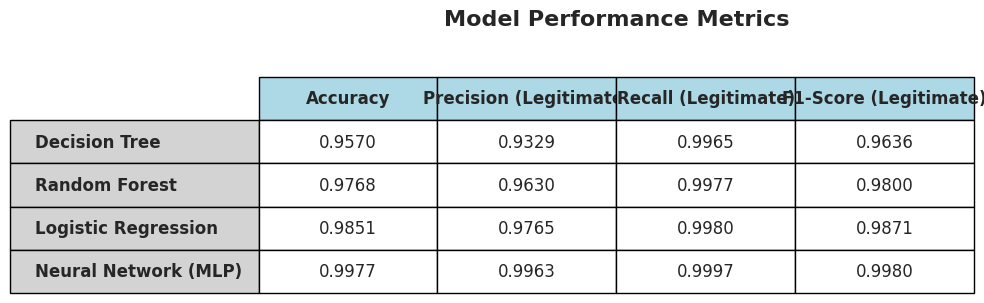

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

model_scores = {
    'Model': [],
    'Accuracy': [],
    'Precision (Legitimate)': [],
    'Recall (Legitimate)': [],
    'F1-Score (Legitimate)': []
}

# Decision Tree
report_dt = classification_report(y_test, dt_pred, output_dict=True)
model_scores['Model'].append('Decision Tree')
model_scores['Accuracy'].append(accuracy_score(y_test, dt_pred))
model_scores['Precision (Legitimate)'].append(report_dt['1']['precision'])
model_scores['Recall (Legitimate)'].append(report_dt['1']['recall'])
model_scores['F1-Score (Legitimate)'].append(report_dt['1']['f1-score'])

# Random Forest
report_rf = classification_report(y_test, rf_pred, output_dict=True)
model_scores['Model'].append('Random Forest')
model_scores['Accuracy'].append(accuracy_score(y_test, rf_pred))
model_scores['Precision (Legitimate)'].append(report_rf['1']['precision'])
model_scores['Recall (Legitimate)'].append(report_rf['1']['recall'])
model_scores['F1-Score (Legitimate)'].append(report_rf['1']['f1-score'])

# Logistic Regression
report_lr = classification_report(y_test, lr_pred, output_dict=True)
model_scores['Model'].append('Logistic Regression')
model_scores['Accuracy'].append(accuracy_score(y_test, lr_pred))
model_scores['Precision (Legitimate)'].append(report_lr['1']['precision'])
model_scores['Recall (Legitimate)'].append(report_lr['1']['recall'])
model_scores['F1-Score (Legitimate)'].append(report_lr['1']['f1-score'])

# Neural Network (MLP)
report_nn = classification_report(y_test, nn_pred, output_dict=True)
model_scores['Model'].append('Neural Network (MLP)')
model_scores['Accuracy'].append(accuracy_score(y_test, nn_pred))
model_scores['Precision (Legitimate)'].append(report_nn['1']['precision'])
model_scores['Recall (Legitimate)'].append(report_nn['1']['recall'])
model_scores['F1-Score (Legitimate)'].append(report_nn['1']['f1-score'])


performance_df = pd.DataFrame(model_scores)
performance_df.set_index('Model', inplace=True)

performance_df_formatted = performance_df.applymap(lambda x: f'{x:.4f}' if isinstance(x, (float, int)) else x)

fig, ax = plt.subplots(figsize=(10, len(performance_df) * 0.8))
ax.axis('off')
ax.set_title('Model Performance Metrics', fontsize=16, fontweight='bold', pad=20)

table = ax.table(
    cellText=performance_df_formatted.values,
    colLabels=performance_df_formatted.columns,
    rowLabels=performance_df_formatted.index,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 0.9]
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

for (i, j), cell in table.get_celld().items():
    cell.set_edgecolor('black')
    cell.set_linewidth(1)
    if i == 0:
        cell.set_facecolor('#ADD8E6')
        cell.set_text_props(weight='bold')
    elif j == -1:
        cell.set_facecolor('#D3D3D3')
        cell.set_text_props(weight='bold')
    else:
        cell.set_facecolor('white')

plt.tight_layout()
plt.savefig('model_performance_table.png', bbox_inches='tight', dpi=300)
plt.show()

Confusion Matrix

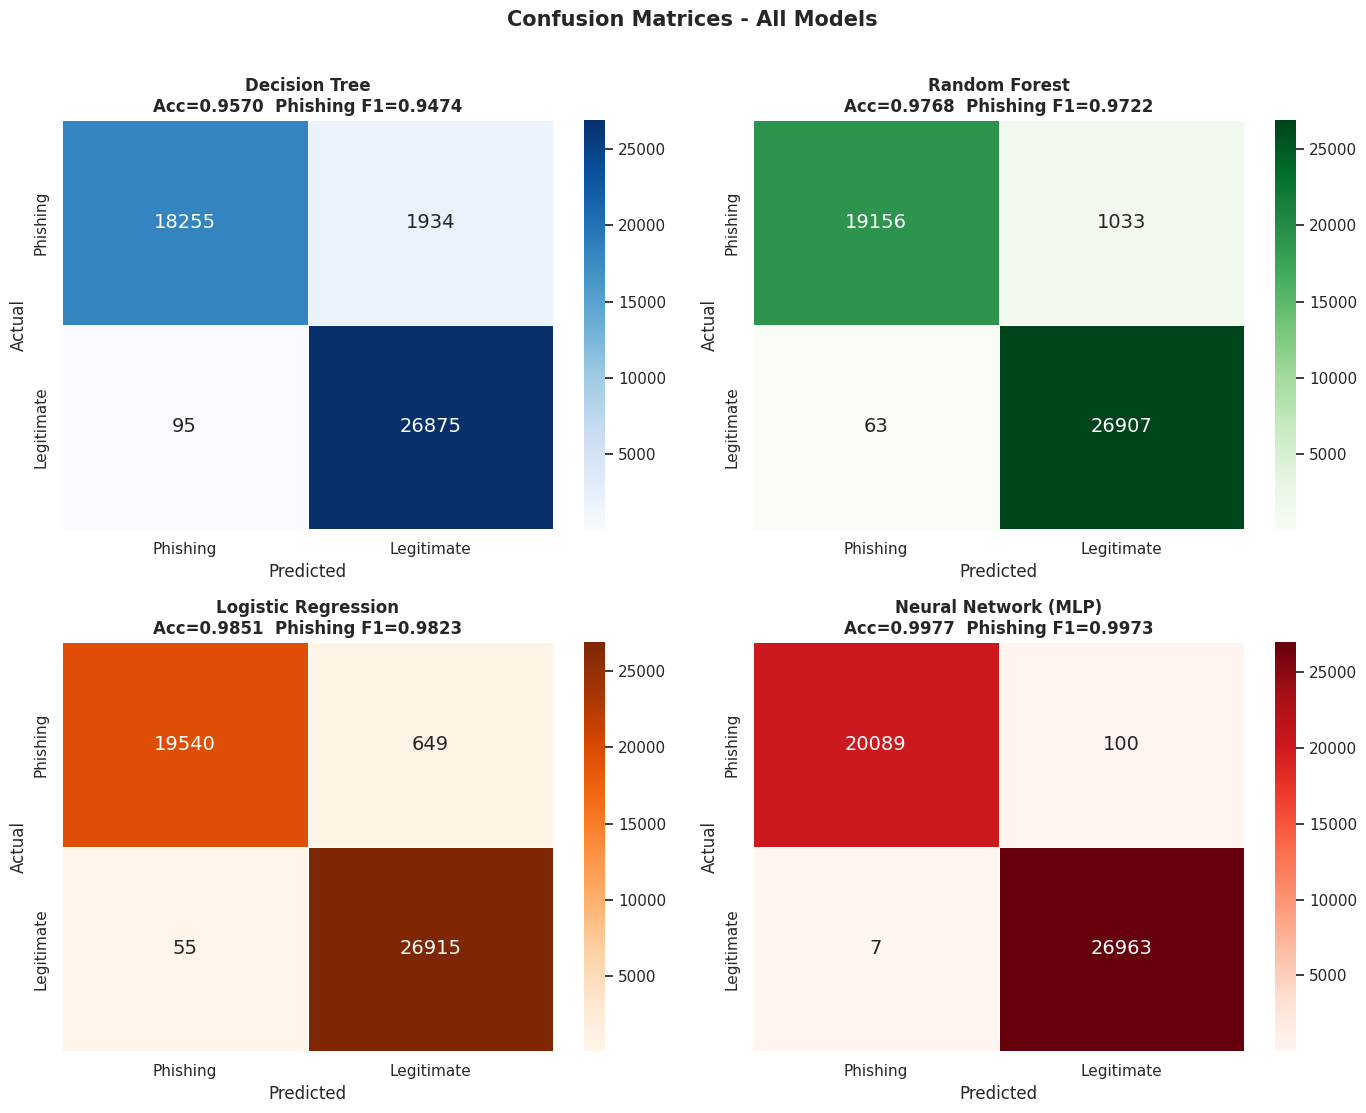

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

# Confusion matrices for all models
all_preds = [dt_pred, rf_pred, lr_pred, nn_pred]
all_names = [
    'Decision Tree',
    'Random Forest',
    'Logistic Regression',
    'Neural Network (MLP)'
]
cmaps = ['Blues', 'Greens', 'Oranges', 'Reds']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, name, preds, cmap in zip(axes, all_names, all_preds, cmaps):
    cm = confusion_matrix(y_test, preds, labels=[0, 1])
    acc = accuracy_score(y_test, preds)
    phishing_f1 = f1_score(y_test, preds, pos_label=0)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        xticklabels=['Phishing', 'Legitimate'],
        yticklabels=['Phishing', 'Legitimate'],
        ax=ax,
        linewidths=0.5,
        annot_kws={'size': 14}
    )

    ax.set_title(
        f'{name}\nAcc={acc:.4f}  Phishing F1={phishing_f1:.4f}',
        fontweight='bold',
        fontsize=12
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices - All Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Presition Recall Curve

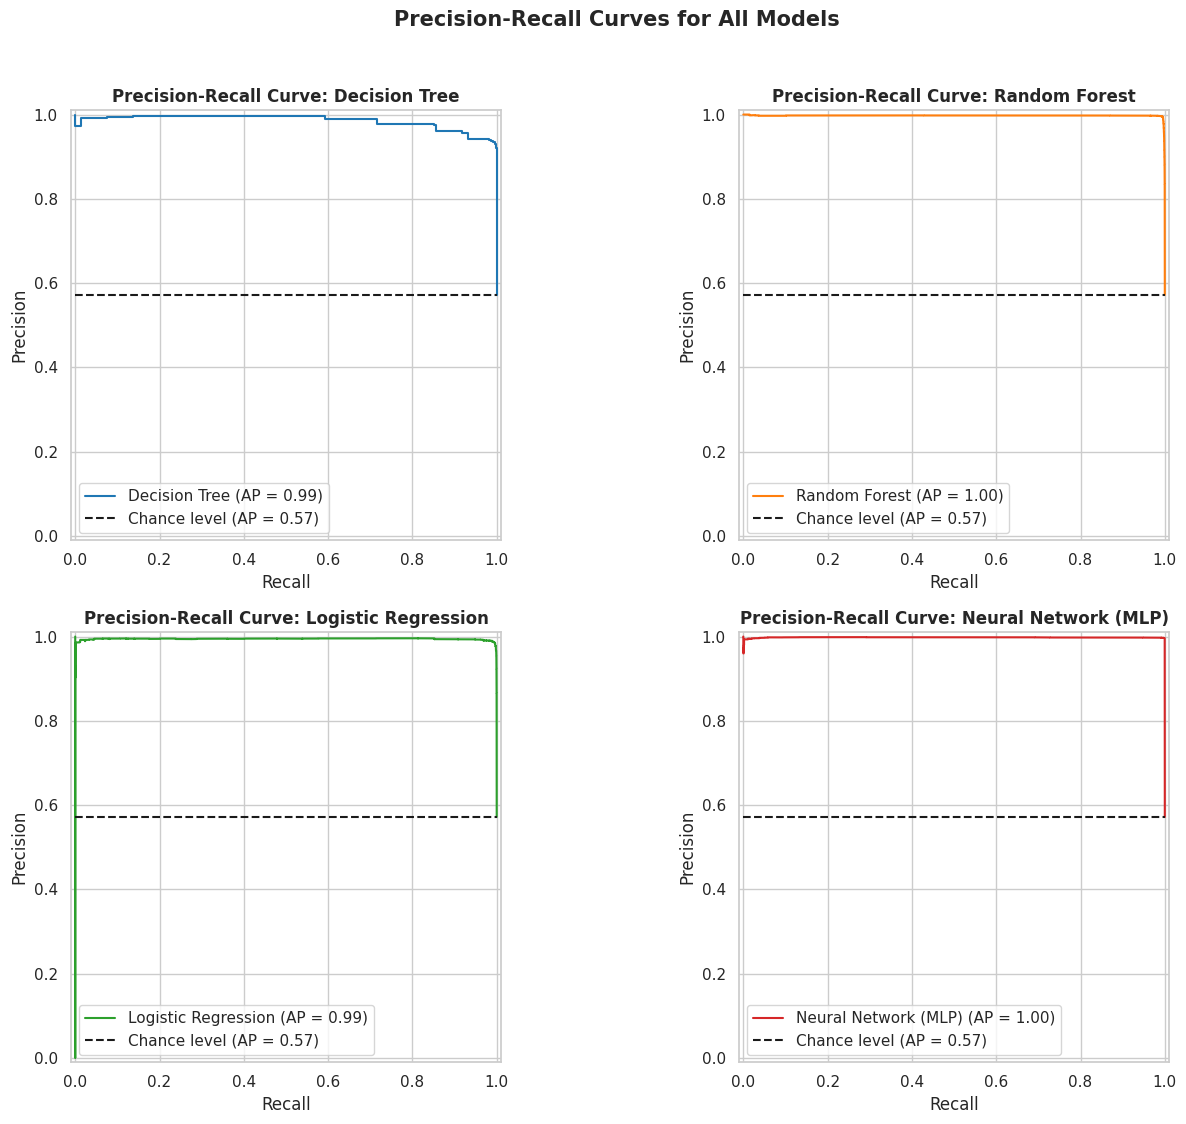

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

models = {
    "Decision Tree": (dt, X_test),
    "Random Forest": (rf, X_test),
    "Logistic Regression": (lr, X_test_sc),
    "Neural Network (MLP)": (nn, X_test_sc)
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (name, (model, X_data)) in enumerate(models.items()):
    ax = axes[i]

    # Get decision function scores or probabilities
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_data)[:, 1]
    else: # For models like SVM, Decision Function might be used
        y_score = model.decision_function(X_data)

    pr_display = PrecisionRecallDisplay.from_predictions(
        y_test,
        y_score,
        name=name,
        ax=ax,
        plot_chance_level=True,
        color=colors[i]
    )

    ax.set_title(f'Precision-Recall Curve: {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(loc='lower left')
    ax.grid(True)

plt.suptitle('Precision-Recall Curves for All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()